# Title: Crime Prediction Project – Los Angeles Data

In [141]:
# Importing the necessary libraries
import mglearn
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Part 1: Data Preprocessing & Exploration: Preparing and exploring the dataset to uncover patterns and ensure data quality for modeling.

In [142]:
# loading the dateset into my notebook
data = pd.read_csv("C:/Users/laryeama/OneDrive - Seton Hall University/Desktop/Fall-2025/Data Mining/project/Crime_Data_from_2020_to_Present (Data for DM Project).csv") 

In [143]:
# Checking the dimensions of the dataset (rows, columns)
data.shape # 

(1004991, 28)

In [144]:
# Display all column names in the dataset
data.columns

Index(['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME',
       'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes',
       'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc',
       'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1',
       'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT',
       'LON'],
      dtype='object')

In [145]:
# Display the first 5 rows of the dataset
data.head

<bound method NDFrame.head of              DR_NO        Date Rptd         DATE OCC  TIME OCC  AREA  \
0        211507896   4/11/2021 0:00   11/7/2020 0:00       845    15   
1        201516622  10/21/2020 0:00  10/18/2020 0:00      1845    15   
2        240913563  12/10/2024 0:00  10/30/2020 0:00      1240     9   
3        210704711  12/24/2020 0:00  12/24/2020 0:00      1310     7   
4        201418201   10/3/2020 0:00   9/29/2020 0:00      1830    14   
...            ...              ...              ...       ...   ...   
1004986  252104112    2/2/2025 0:00    2/2/2025 0:00       130    21   
1004987  250404100   2/18/2025 0:00   2/18/2025 0:00      1000     4   
1004988  251304095   1/31/2025 0:00   1/30/2025 0:00      1554    13   
1004989  251704066   1/17/2025 0:00   1/17/2025 0:00      1600    17   
1004990  251904210   3/25/2025 0:00   3/25/2025 0:00      1235    19   

           AREA NAME  Rpt Dist No  Part 1-2  Crm Cd  \
0        N Hollywood         1502         2     35

In [146]:
# Dropping redandunt columns
# Variables droped here are redundant as the data contain other columns with equal useful information. Eg. Weapon used code is droped while Weapon Description is maintained
data.drop(columns=['DR_NO', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Mocodes', 'LOCATION', 'Cross Street', 'Premis Cd','Part 1-2','Status','Weapon Used Cd', 'Date Rptd', 'AREA'], inplace=True)


In [147]:
# Checking the dimensions of the dataset after droping redundant columns
data.shape

(1004991, 14)

In [148]:
# identifying the number of duplicate rows in the dataset
data.duplicated().sum() 

4873

In [149]:
# dropping the duplicate rows
data = data.drop_duplicates() 

In [150]:
# displaying the types of data after droping the redundant and duplicate rows
print(f'the types of data in each column is:')
data.dtypes

the types of data in each column is:


DATE OCC         object
TIME OCC          int64
AREA NAME        object
Rpt Dist No       int64
Crm Cd            int64
Crm Cd Desc      object
Vict Age          int64
Vict Sex         object
Vict Descent     object
Premis Desc      object
Weapon Desc      object
Status Desc      object
LAT             float64
LON             float64
dtype: object

In [151]:
# See count of NaN values per column
print(data.isnull().sum())

DATE OCC             0
TIME OCC             0
AREA NAME            0
Rpt Dist No          0
Crm Cd               0
Crm Cd Desc          0
Vict Age             0
Vict Sex        143316
Vict Descent    143328
Premis Desc        587
Weapon Desc     674757
Status Desc          0
LAT                  0
LON                  0
dtype: int64


In [152]:
# Remove rows with missing values in critical columns
data = data.dropna(subset=['Vict Sex', 'Vict Descent', 'Weapon Desc', 'Premis Desc']) 

In [153]:
#Get unique values in 'Vict Age' column
unique_values = data['Vict Age'].unique()
print(unique_values) 

[32 14 13 26 21 37 19 43 49 39 58  0 18 11 57 53 68 28 27 17 60 31 52 46
 23 24 35 40 48 25 41 70 22 50 29 42 59 63 56 20 47  7 36 45 79 54 62 65
 33 30 34 38 61 96 16  8 77 44 51 67 64  4 71 66 80 12 55 75 15 69  3 10
  9 73  6 74 90 82 91 72 78 81 76  2 87 84 83 88 89  5 85 95 93 99 86 -2
 97 -4 -1 92 94 98]


In [154]:
# Remove negative ages explicitly
data = data[data['Vict Age'] >= 0]

In [155]:
#Get unique values in 'Age' column
unique_values = data['Vict Age'].unique()
print(unique_values)

[32 14 13 26 21 37 19 43 49 39 58  0 18 11 57 53 68 28 27 17 60 31 52 46
 23 24 35 40 48 25 41 70 22 50 29 42 59 63 56 20 47  7 36 45 79 54 62 65
 33 30 34 38 61 96 16  8 77 44 51 67 64  4 71 66 80 12 55 75 15 69  3 10
  9 73  6 74 90 82 91 72 78 81 76  2 87 84 83 88 89  5 85 95 93 99 86 97
 92 94 98]


In [156]:
# Inspecting the unique values in each column to understand categories, detect unexpected values,and spot potential data quality issues (e.g., mixed formats or rare labels).
for col in data.columns:
    print(f"Unique values in {col}: {data[col].unique()}")

Unique values in DATE OCC: ['10/18/2020 0:00' '7/7/2020 0:00' '6/20/2020 0:00' ... '1/29/2025 0:00'
 '2/27/2025 0:00' '1/17/2025 0:00']
Unique values in TIME OCC: [1845 1400    1 ...  654 1431  741]
Unique values in AREA NAME: ['N Hollywood' 'Northeast' 'Hollywood' 'Southeast' 'Devonshire' 'Pacific'
 'Foothill' 'Mission' 'Olympic' 'Topanga' 'Newton' 'Rampart' 'Wilshire'
 'West Valley' 'West LA' 'Central' 'Van Nuys' '77th Street' 'Hollenbeck'
 'Harbor' 'Southwest']
Unique values in Rpt Dist No: [1521 1133  657 ...  936  672  934]
Unique values in Crm Cd: [230 812 626 624 310 210 627 930 860 350 330 236 740 220 760 761 623 648
 480 122 745 900 625 440 821 121 753 250 231 437 946 251 647 820 815 320
 901 888 237 421 420 813 341 910 886 110 931 435 928 810 755 354 235 763
 956 520 622 662 940 922 903 442 351 474 410 113 450 920 331 434 921 822
 510 850 762 441 343 756 943 902 951 805 443 352 436 522 950 649 944 664
 668 451 438 933 890 473 670 666 475 845 924 452 840 806 661 439 814 932
 8

In [157]:
# Checking the dimensions of the dataset after initial cleaning
data.shape

(325064, 14)

In [158]:
# Display all column names in the dataset after initail cleaning
data.columns

Index(['DATE OCC', 'TIME OCC', 'AREA NAME', 'Rpt Dist No', 'Crm Cd',
       'Crm Cd Desc', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Desc',
       'Weapon Desc', 'Status Desc', 'LAT', 'LON'],
      dtype='object')

In [159]:
# Convert the date and time to enable time series operation
data['DATE OCC'] = pd.to_datetime(data['DATE OCC'])
data['Hour'] = data['TIME OCC'] // 100
data['DayOfWeek'] = data['DATE OCC'].dt.day_name()
data['Year'] = data['DATE OCC'].dt.year

In [160]:
# Remove outliers based on LA bounds
valid_data = data[(data['LAT'].between(33, 35)) & (data['LON'].between(-119, -117))] 

In [161]:
# Checking the dimensions of the valid dataset for the project
valid_data.shape 

(324235, 17)

# Defining Violent Crime 

In [162]:
# Violent crime definition 
violent_crime_keywords = [
    'ASSAULT', 'BATTERY', 'ROBBERY', 'HOMICIDE', 'MANSLAUGHTER', 'LYNCHING',
    'RAPE', 'SEXUAL', 'KIDNAPPING', 'BRANDISH', 'DISCHARGE FIREARMS',
    'SHOTS FIRED', 'THROWING OBJECT', 'ARSON', 'FALSE IMPRISONMENT',
    'HUMAN TRAFFICKING', 'CHILD ABUSE', 'LEWD', 'SODOMY', 'ORAL COPULATION'
]

violent_weapon_keywords = [
    'GUN', 'FIREARM', 'RIFLE', 'SHOTGUN', 'PISTOL', 'REVOLVER',
    'KNIFE', 'BLADE', 'AXE', 'SWORD', 'MACHETE', 'STUN GUN',
    'EXPLOSIVE', 'BOMB', 'BRASS KNUCKLES', 'BLUNT INSTRUMENT',
    'MACE', 'PEPPER SPRAY'
]
# Create a Boolean mask for violent crime
mask = (
   valid_data['Crm Cd Desc'].str.contains('|'.join(violent_crime_keywords), case=False, na=False) |
   valid_data['Weapon Desc'].str.contains('|'.join(violent_weapon_keywords), case=False, na=False)
)

# Create the new DataFrame
violent_crime = valid_data[mask].copy()

In [163]:
# Checking the dimensions of the vailent crime dataset for violent crime
violent_crime.shape

(271821, 17)

In [164]:
# Select all non-violent crime records (inverse of mask) and make a copy
non_violent_crime = valid_data[~mask].copy()

In [165]:
# Checking the dimensions of the non-violent crime dataset for violent crime
non_violent_crime.shape

(52414, 17)

# Visual Analysis:

## Spatial Patterns

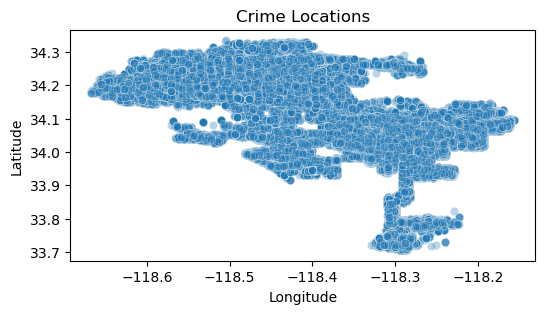

In [166]:
# Plot crime locations on a scatter plot using latitude and longitude
import seaborn as sns
plt.figure(figsize=(6,3))
sns.scatterplot(x='LON', y='LAT', data=valid_data, alpha=0.3)
plt.title('Crime Locations')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

# Top 20 List of Crimes in Los Angelis

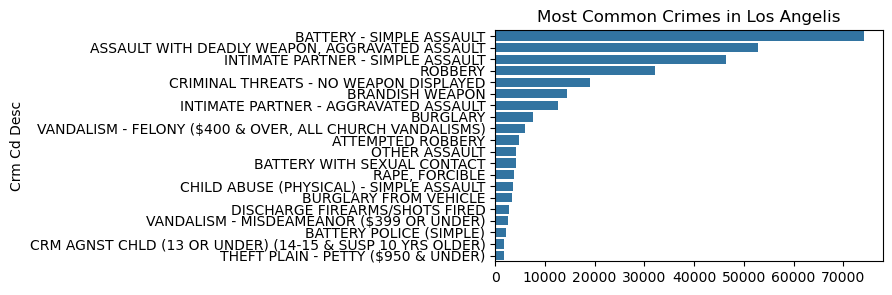

In [167]:
plt.figure(figsize=(5,3))
top_crimes = valid_data['Crm Cd Desc'].value_counts().head(20)
sns.barplot(x=top_crimes.values, y=top_crimes.index)
plt.title('Most Common Crimes in Los Angelis')
plt.show()

# Top 10 List of Violent Crimes in Los Angelis

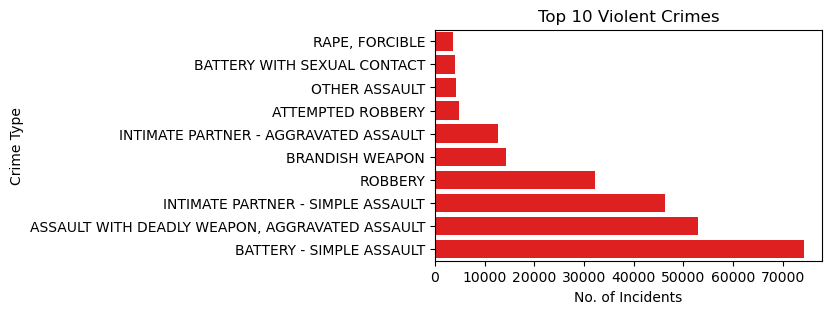

In [168]:
plt.figure(figsize=(5,3))

# Get top 10 violent crimes in ascending order
top_crimes = violent_crime['Crm Cd Desc'].value_counts().head(10).sort_values(ascending=True)

# Plot with red color
sns.barplot(x=top_crimes.values, y=top_crimes.index, color='red')

plt.title('Top 10 Violent Crimes')
plt.xlabel('No. of Incidents')
plt.ylabel('Crime Type')
plt.show()


# Top 10 List of Non Violent Crimes in Los Angelis

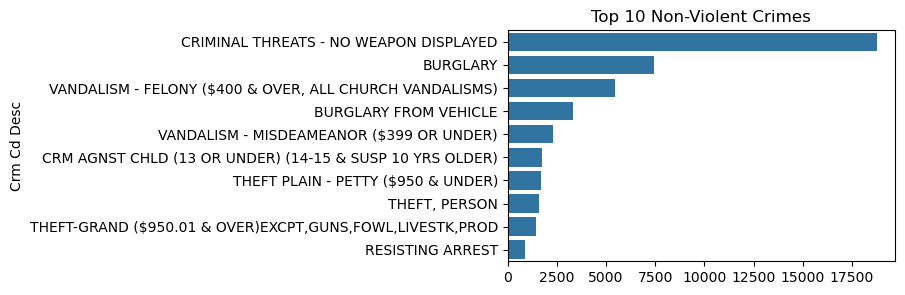

In [169]:
plt.figure(figsize=(5,3))
top_crimes = non_violent_crime['Crm Cd Desc'].value_counts().head(10)
sns.barplot(x=top_crimes.values, y=top_crimes.index)
plt.title('Top 10 Non-Violent Crimes')
plt.show()

# Overall Crime Hot Spots 

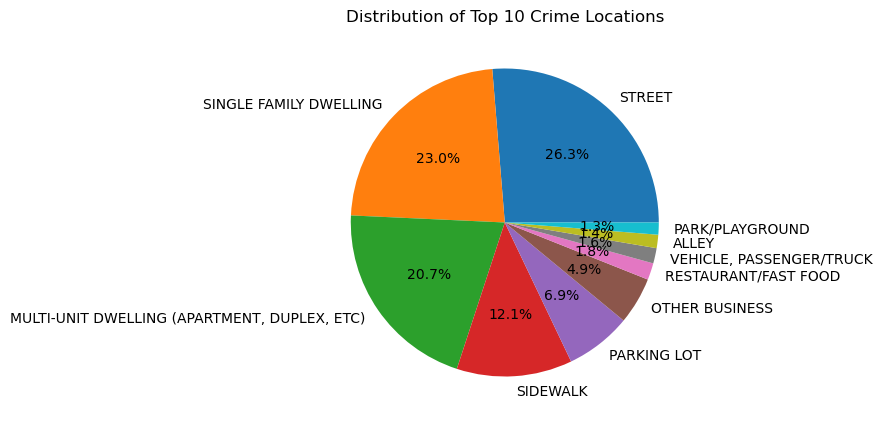

In [170]:
# plots just the top 10 Premises
top10_premises = valid_data['Premis Desc'].value_counts().head(10)

# Plot pie chart
top10_premises.plot.pie(autopct='%1.1f%%', figsize=(6,5))
plt.title("Distribution of Top 10 Crime Locations")
plt.ylabel('')  # Remove the default y-label
plt.show() 

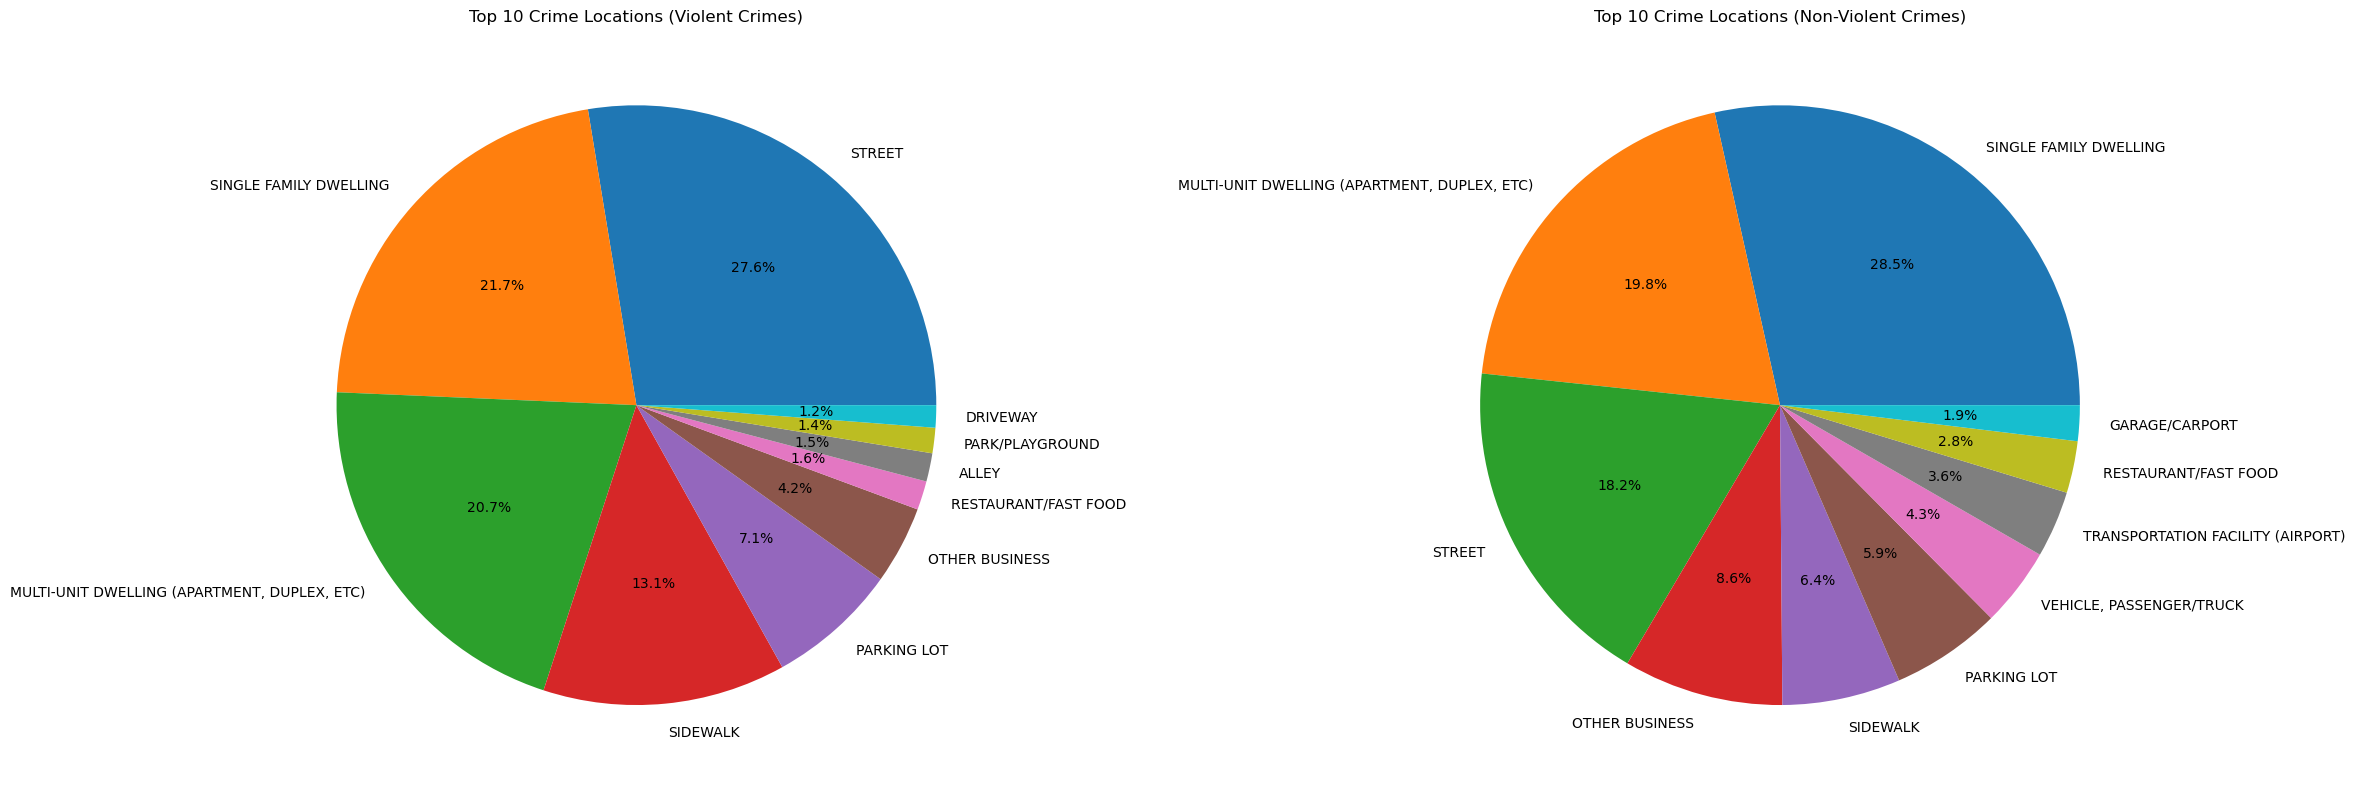

In [171]:

# Top 10 premises for each dataset
top10_violent = violent_crime['Premis Desc'].value_counts().head(10)
top10_nonviolent = non_violent_crime['Premis Desc'].value_counts().head(10)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 8))  # 1 row, 2 columns

# Plot for violent crimes
top10_violent.plot.pie(autopct='%1.1f%%', ax=axes[0])
axes[0].set_title("Top 10 Crime Locations (Violent Crimes)")
axes[0].set_ylabel('')

# Plot for non-violent crimes
top10_nonviolent.plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title("Top 10 Crime Locations (Non-Violent Crimes)")
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


# Which Specific Areas do the Top 10 Violent and Non Violent Crimes Occur?

C:\Users\laryeama\AppData\Local\Temp\ipykernel_20112\3402761529.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(violent_top10.index, rotation=90)
C:\Users\laryeama\AppData\Local\Temp\ipykernel_20112\3402761529.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(nonviolent_top10.index, rotation=90)


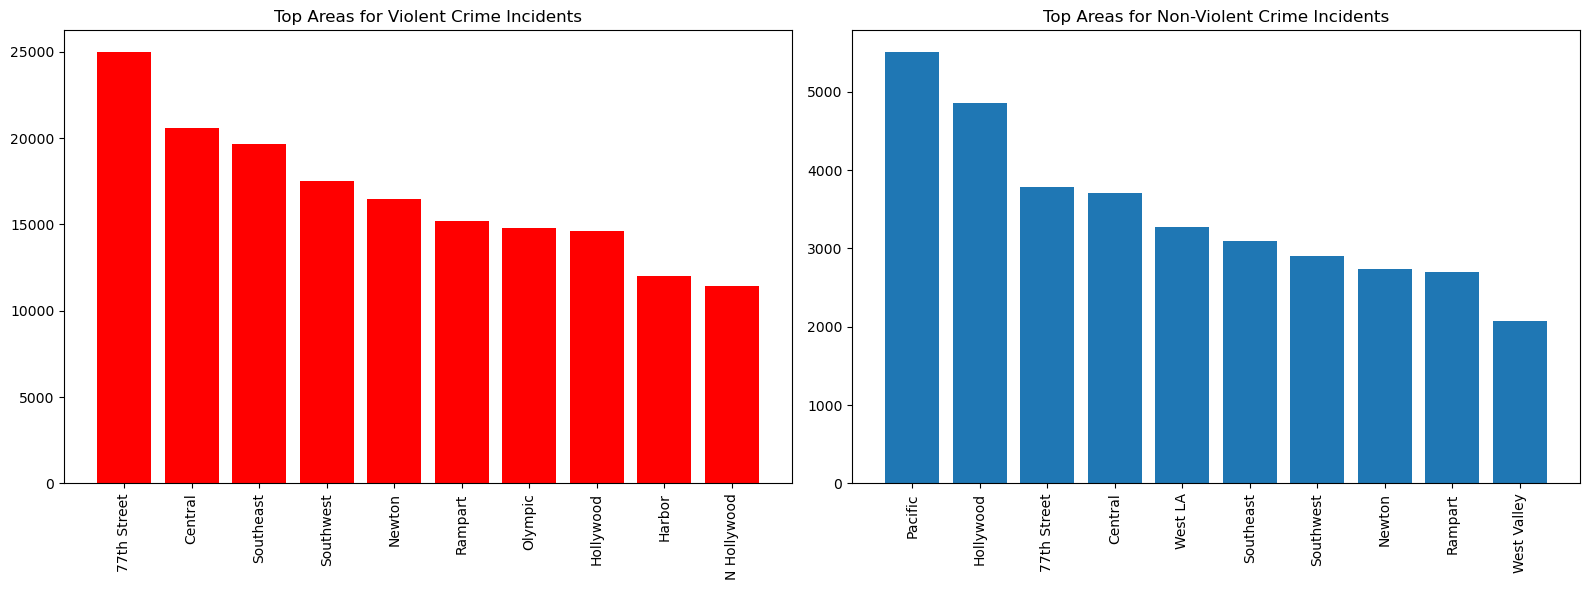

In [172]:
# violent_crime['AREA NAME'].value_counts().head(10).plot(kind='bar')
# import matplotlib.pyplot as plt

# Get top 10 area names for each
violent_top10 = violent_crime['AREA NAME'].value_counts().head(10)
nonviolent_top10 = non_violent_crime['AREA NAME'].value_counts().head(10)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violent crimes
axes[0].bar(violent_top10.index, violent_top10.values,color= 'red')
axes[0].set_title("Top Areas for Violent Crime Incidents")
axes[0].set_xticklabels(violent_top10.index, rotation=90)

# Non-violent crimes
axes[1].bar(nonviolent_top10.index, nonviolent_top10.values)
axes[1].set_title("Top Areas for Non-Violent Crime Incidents")
axes[1].set_xticklabels(nonviolent_top10.index, rotation=90)

plt.tight_layout()
plt.show() 

# Crime Patterns Across Days and Hours

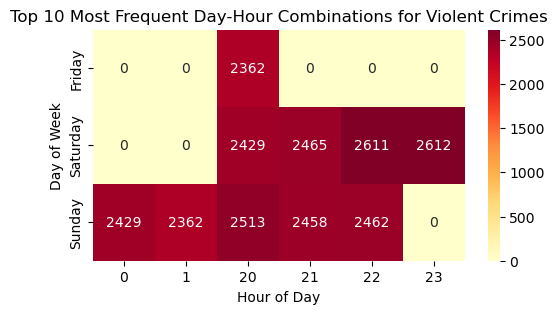

In [173]:
#Group and count
top10 = (violent_crime.groupby(['DayOfWeek', 'Hour']).size().reset_index(name='count').sort_values(by='count', ascending=False).head(10))

#Pivot for heatmap
heatmap_data = top10.pivot(index='DayOfWeek', columns='Hour', values='count').fillna(0)

#Plot heatmap
plt.figure(figsize=(6,3))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".0f")
plt.title("Top 10 Most Frequent Day-Hour Combinations for Violent Crimes")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

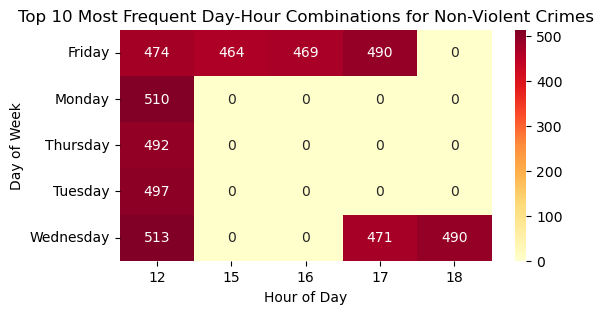

In [174]:
#Group and count
top10 = (non_violent_crime.groupby(['DayOfWeek', 'Hour']).size().reset_index(name='count').sort_values(by='count', ascending=False).head(10))

#Pivot for heatmap
heatmap_data = top10.pivot(index='DayOfWeek', columns='Hour', values='count').fillna(0)

#Plot heatmap
plt.figure(figsize=(6,3))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt=".0f")
plt.title("Top 10 Most Frequent Day-Hour Combinations for Non-Violent Crimes")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()


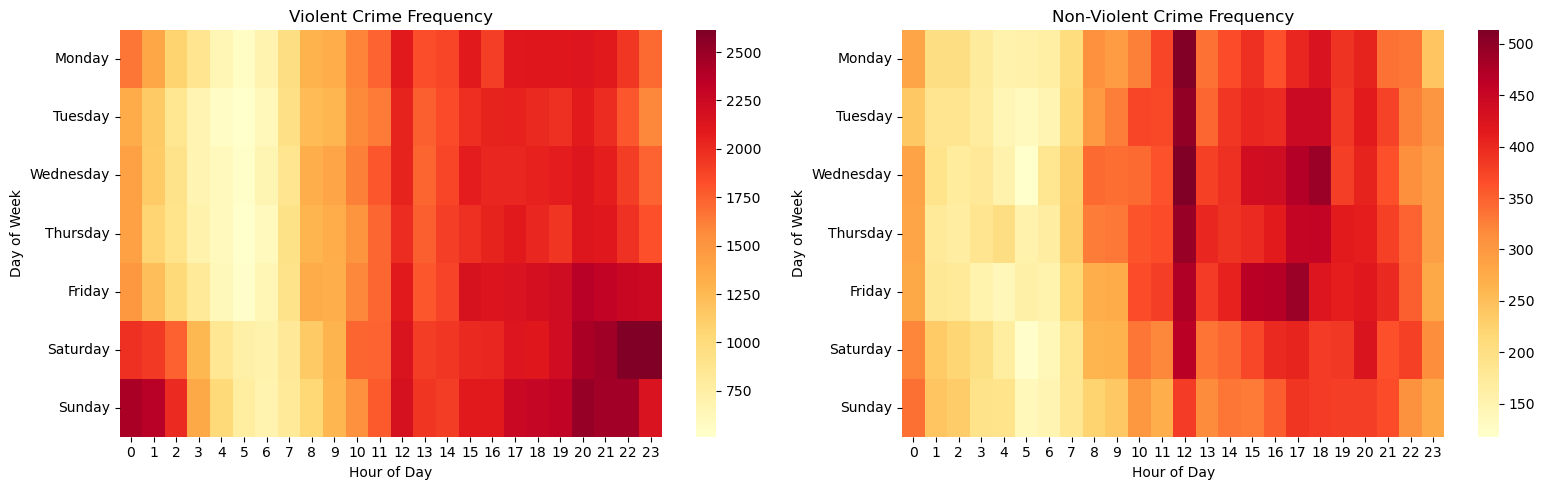

In [175]:
# Create heatmap data for violent crimes
violent_heatmap = violent_crime.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)
violent_heatmap = violent_heatmap.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

# Create heatmap data for non-violent crimes
nonviolent_heatmap = non_violent_crime.groupby(['DayOfWeek', 'Hour']).size().unstack(fill_value=0)
nonviolent_heatmap = nonviolent_heatmap.reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(16,5))  # 1 row, 2 columns

sns.heatmap(violent_heatmap, cmap='YlOrRd', ax=axes[0])
axes[0].set_title("Violent Crime Frequency")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Day of Week")

sns.heatmap(nonviolent_heatmap, cmap='YlOrRd', ax=axes[1])
axes[1].set_title("Non-Violent Crime Frequency")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Day of Week")

plt.tight_layout()
plt.show()


# Victim Related Patterns

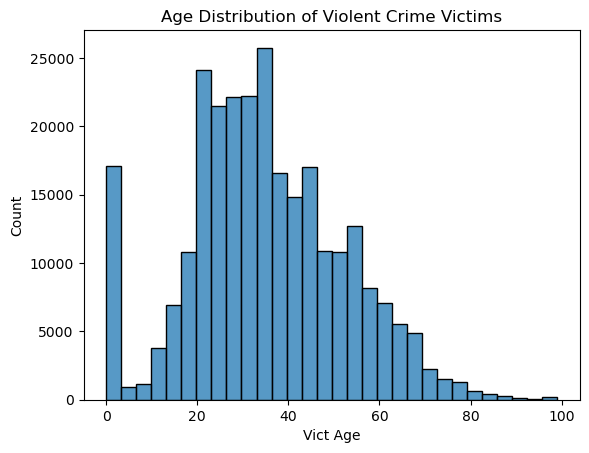

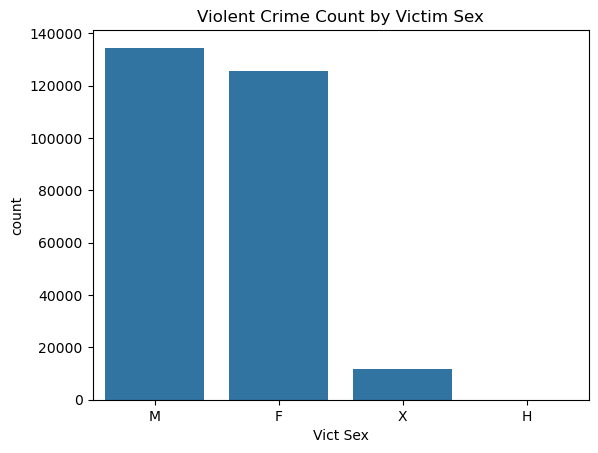

In [176]:
# violent crime distribution
sns.histplot(violent_crime['Vict Age'], bins=30)
plt.title('Age Distribution of Violent Crime Victims')
plt.show()

sns.countplot(x='Vict Sex', data=violent_crime)
plt.title('Violent Crime Count by Victim Sex')
plt.show()

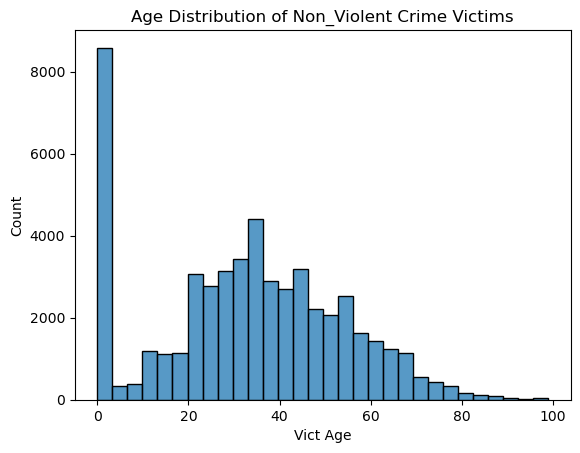

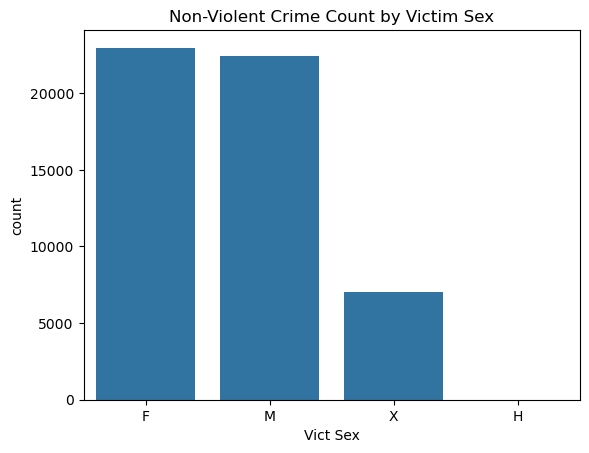

In [177]:
# non_violent crime distribution
sns.histplot(non_violent_crime['Vict Age'], bins=30)
plt.title('Age Distribution of Non_Violent Crime Victims')
plt.show()

sns.countplot(x='Vict Sex', data=non_violent_crime)
plt.title('Non-Violent Crime Count by Victim Sex')
plt.show()

In [178]:
# non_violent_crime['Vict Sex'].value_counts()

# Lets Visualize the Top 10 Victim Descent by their Gender

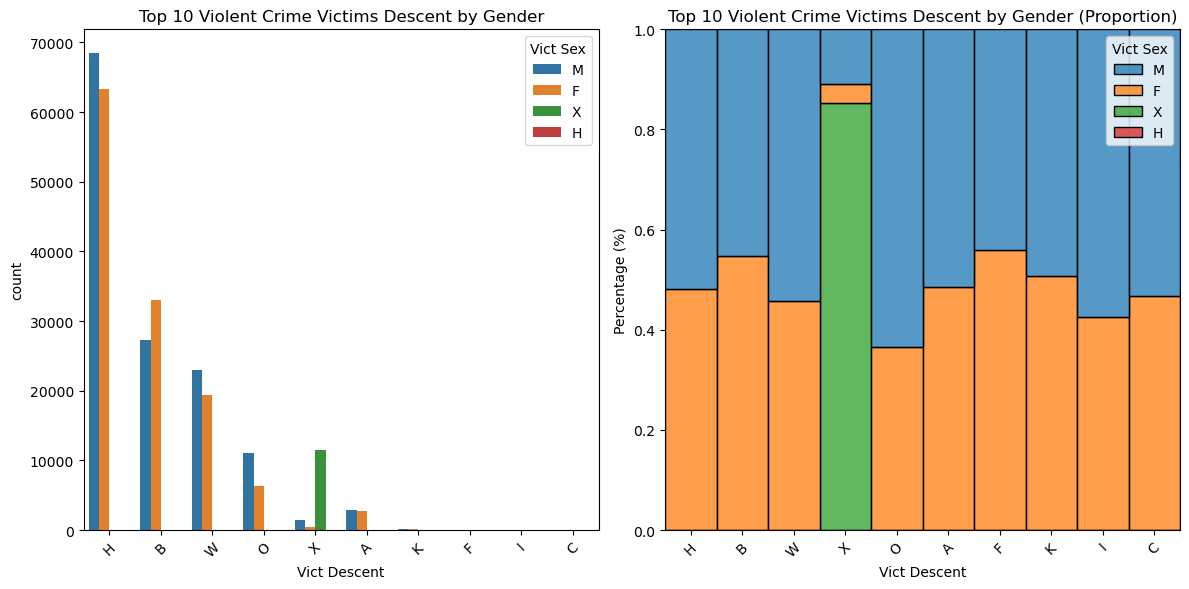

In [179]:
import seaborn as sns

# Get top 10 most common victim descents
top10_descent = violent_crime['Vict Descent'].value_counts().head(10).index
data_top10 = violent_crime[violent_crime['Vict Descent'].isin(top10_descent)].copy()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Countplot 
sns.countplot(ax=axes[0],x='Vict Descent',hue='Vict Sex',data=data_top10, order=top10_descent)
axes[0].set_title("Top 10 Violent Crime Victims Descent by Gender")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Histogram with proportions
sns.histplot( ax=axes[1],data=data_top10,x='Vict Descent',hue='Vict Sex',multiple='fill', ) # stacks to 100%stat='percent'     # show percentages)
axes[1].set_title("Top 10 Violent Crime Victims Descent by Gender (Proportion)")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


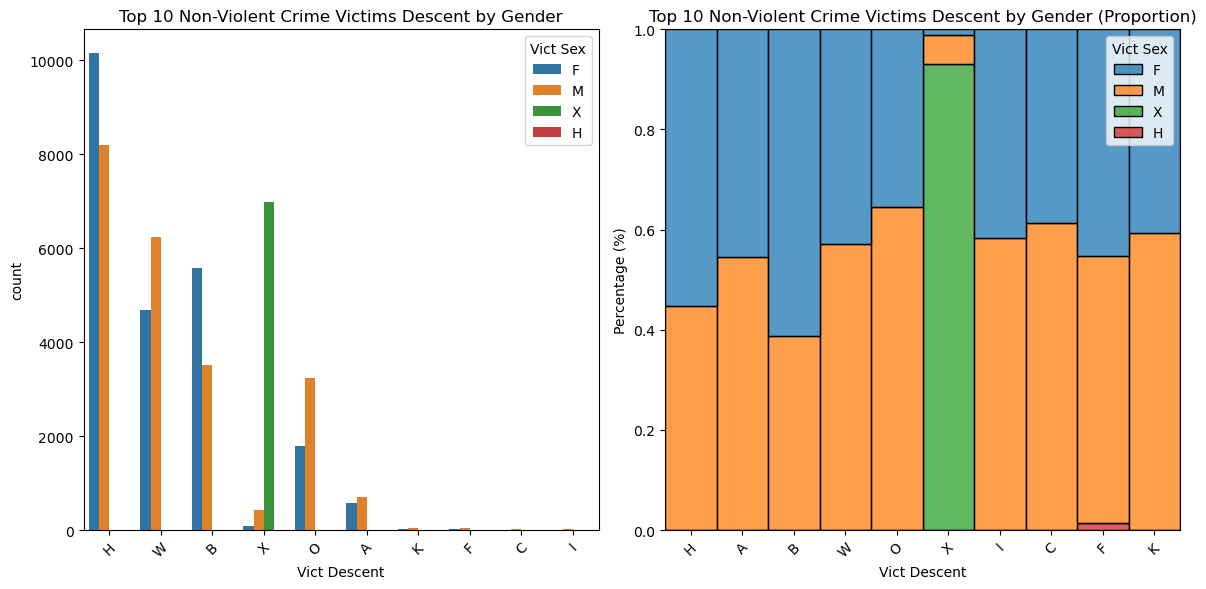

In [180]:

# Get top 10 most common victim descents
top10_descent = non_violent_crime['Vict Descent'].value_counts().head(10).index
data_top10 = non_violent_crime[non_violent_crime['Vict Descent'].isin(top10_descent)].copy()

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Countplot 
sns.countplot(ax=axes[0],x='Vict Descent',hue='Vict Sex',data=data_top10, order=top10_descent)
axes[0].set_title("Top 10 Non-Violent Crime Victims Descent by Gender")
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Histogram with proportions
sns.histplot( ax=axes[1],data=data_top10,x='Vict Descent',hue='Vict Sex',multiple='fill', ) # stacks to 100%stat='percent'     # show percentages)
axes[1].set_title("Top 10 Non-Violent Crime Victims Descent by Gender (Proportion)")
axes[1].set_ylabel("Percentage (%)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


# Findings Summary Based on the Data Preprocessing & Exploration

### Exploratory Visualizations
- **Spatial Distribution:** Plot of latitude and longitude shows crime incidents are concentrated throughout Los Angeles.
- **Crime Type Analysis:**
  - overall crimes reveal offenses such as assaaul, robbery, burglary and burglary are most common 
    - Violent: Assault (simple and aggravated) with deadly weapon, battery and robbery.
    - Non-violent: criminal threat, burglary and vandalism.
- **Premises Analysis:** top crime locations include streets, sidewalks, and residential areas.
- **Area-Level Patterns:** neighborhoods like 77th Street, Central, Southeast and Southwest are hotspots for crimes.
- **Temporal Patterns:** 
  - Violent crimes peak on weekends (sundays from early morning and Fri/Sat from 8pm into late night).
  - Non-violent crimes show weekday activities with 12 pm as peak period.
- **Victim Demographics:**
  - violent crime victims are mostly aged 15–35, with more males than females.
  - Ethnicity charts indicate Hispanic, Black, and White groups as most affected.
### Key Insight
- Crime patterns are strongly influenced by **location**, **time of day**, and **victim demographics**.